In [100]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
## Import el archivo
solicitantes = pd.read_excel('/content/drive/MyDrive//3. Vacation_Data.xlsx')
solicitantes.head()
solicitantes.shape


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(820, 5)

In [101]:
print(solicitantes.groupby('Rental').size())

Rental
0    513
1    307
dtype: int64


In [102]:
print("La variable children indica el numero de hijos que tiene la persona, la variable Age indica la edad, Income se refiere a los ingresos. Como variable dependiente esta RENTAL y las demas son independientes.")

La variable children indica el numero de hijos que tiene la persona, la variable Age indica la edad, Income se refiere a los ingresos. Como variable dependiente esta RENTAL y las demas son independientes.


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


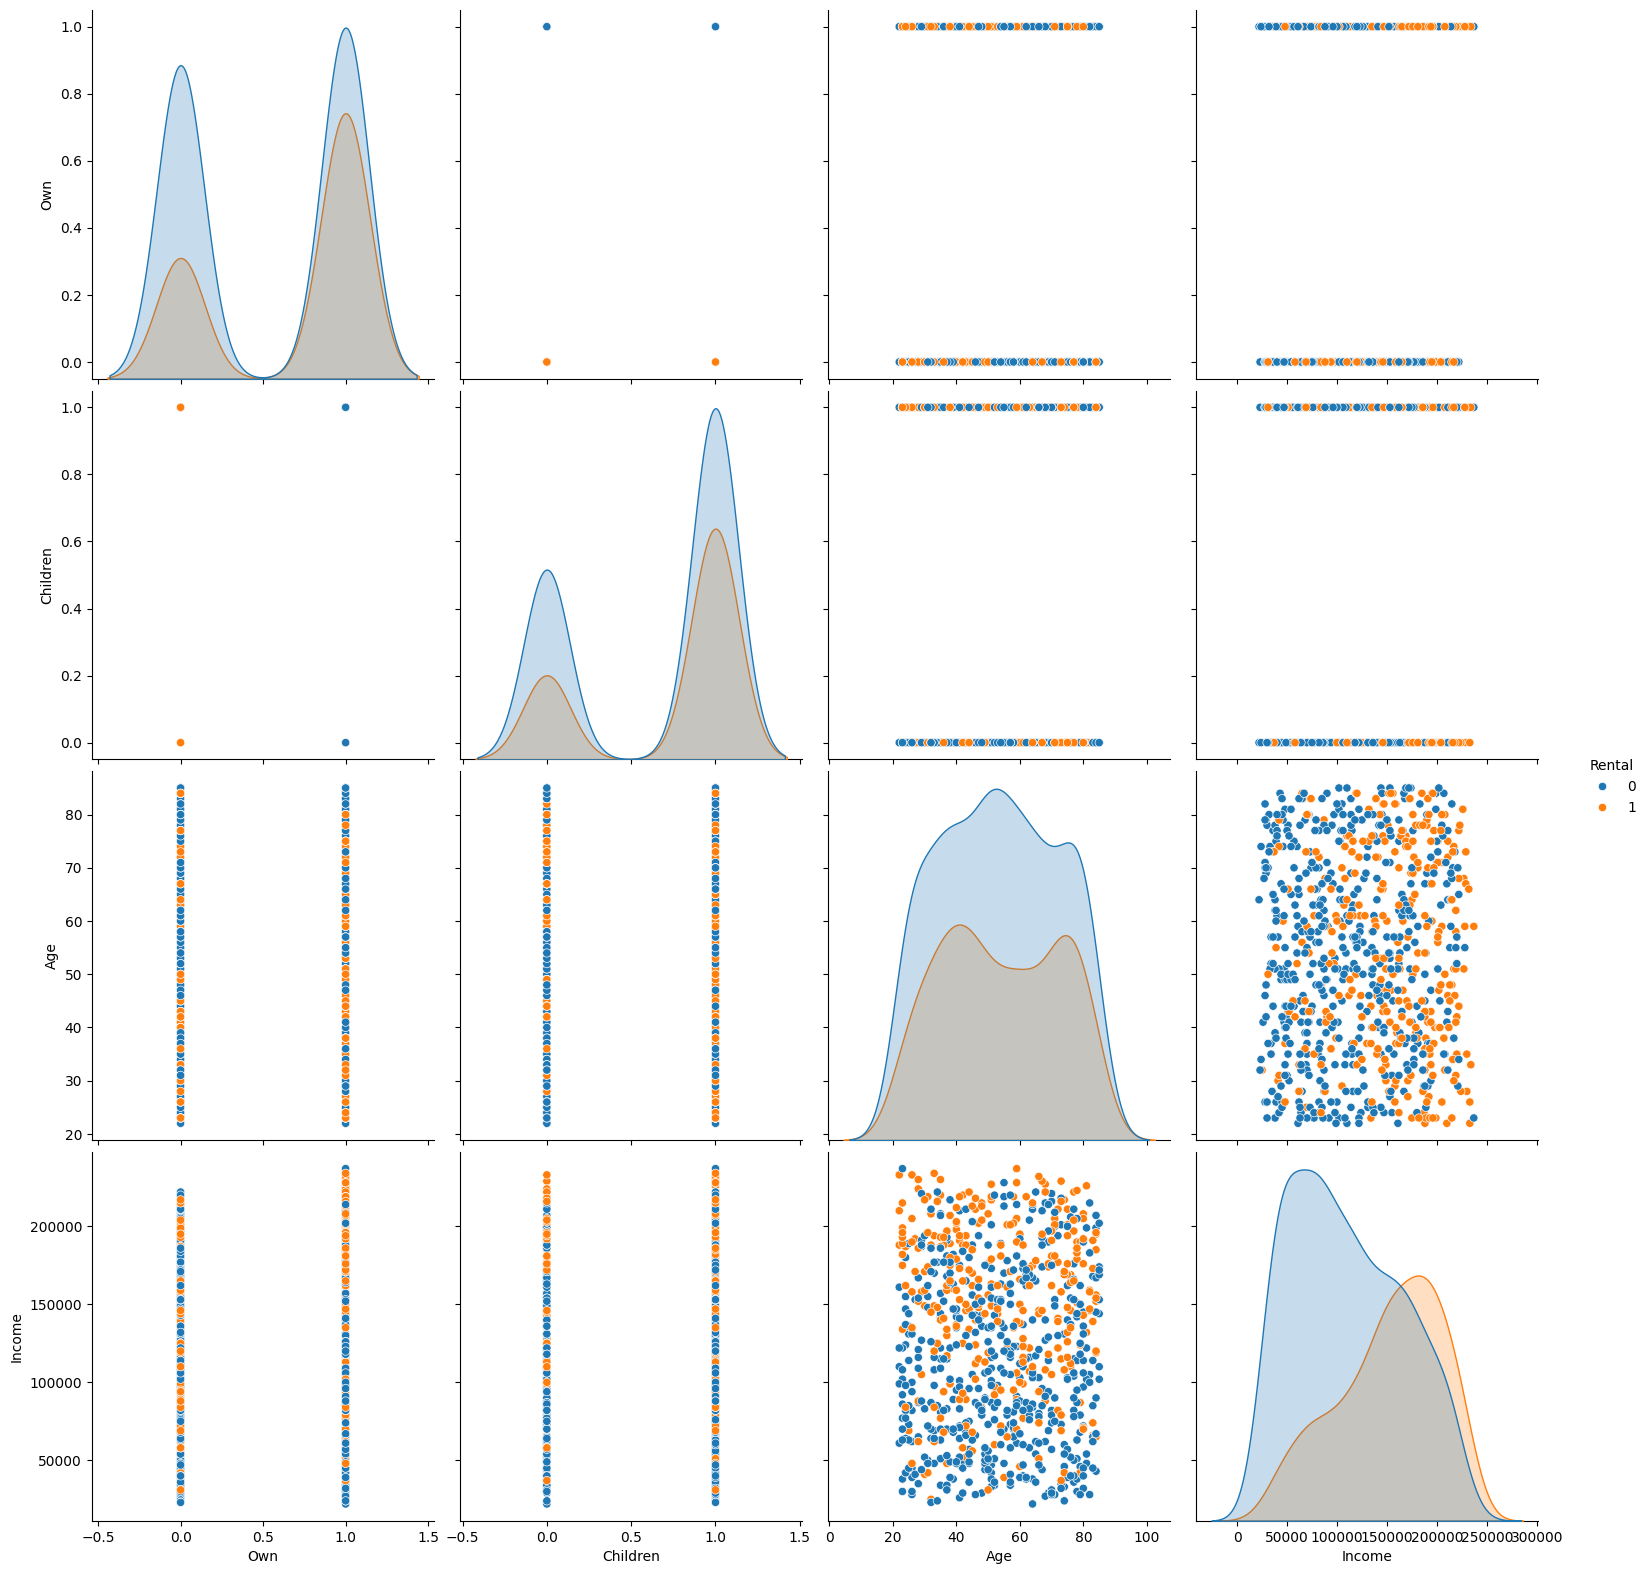

In [103]:
import seaborn as sns
sns.pairplot(solicitantes, hue='Rental', size=4, vars=['Own','Children','Age','Income'])

In [104]:
XD = solicitantes[['Own','Children','Age','Income']]
XD

,Own,Children,Age,Income
0,0,1,41,64000
1,1,0,64,22000
2,1,1,38,189000
3,0,1,36,94000
4,0,1,79,150000
...,...,...,...,...
815,0,1,73,69000
816,1,1,55,120000
817,0,0,67,195000
818,0,0,64,110000


In [105]:
## Escojo la varible dependiente del modelo

YD = solicitantes['Rental'].dropna()

import numpy as np
## Construimos la matriz de correlación de las variables independientes

dfinf = pd.DataFrame(np.column_stack((XD,YD)))
dfinf.columns=['Own','Children','Age','Income','Rental']
dfinf.corr()
mCorr = dfinf.corr()
mCorr

,Own,Children,Age,Income,Rental
Own,1.000000,0.042532,0.067497,0.040827,0.156361
Children,0.042532,1.000000,-0.039087,-0.028243,0.086952
Age,0.067497,-0.039087,1.000000,0.005616,0.017890
Income,0.040827,-0.028243,0.005616,1.000000,0.355934
Rental,0.156361,0.086952,0.017890,0.355934,1.000000


<Axes: >

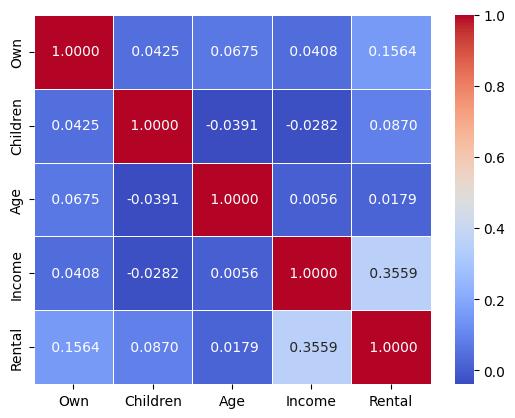

In [106]:
sns.heatmap(mCorr, cmap = 'coolwarm', linewidth = 0.5, annot = True, fmt = ' .4f')

In [107]:
print ("La variable que mas influye en el resultado es Own, a su vez, las variables Own y Income son las que mas correlacion tienen. ")

La variable que mas influye en el resultado es Own, a su vez, las variables Own y Income son las que mas correlacion tienen. 


In [108]:
## Convierto los datasets a arrays
XDArray = np.array(XD, dtype = float)
YDArray = np.array(YD, dtype = float)

In [109]:
from sklearn.neighbors import KNeighborsClassifier
KnnModel = KNeighborsClassifier(n_neighbors = 10)

In [110]:
KnnModel.fit(XDArray, YDArray)
ydPred = KnnModel.predict(XDArray)
ydPred

array([0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 0., 1.

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CM= confusion_matrix(YDArray, ydPred)
CM


array([[446,  67],
       [180, 127]])

In [112]:
### Exactitud
print(f'La exactitud  es {(CM[1][1]+CM[0][0])/CM.sum():.4%}')
## Sensibilidad
print(f'La sensibilidad  es {CM[1][1]/(CM[1][1]+CM[1][0]):.4%}')
## Especificidad
print(f'La especificidad es {CM[0][0]/(CM[0][0]+CM[0][1]):.4%}')

La exactitud  es 69.8780%
La sensibilidad  es 41.3681%
La especificidad es 86.9396%


In [114]:

from sklearn.metrics import roc_auc_score
roc_auc_score(YDArray, ydPred)

0.6415382466299662

In [115]:
XDi = np.array([(0, 0, 58, 83931)])
Ydi = KnnModel.predict(XDi)
print(f'La decisión frente a rentar o no es:{Ydi}')

La decisión frente a rentar o no es:[0.]


### **OWN VS AGE**

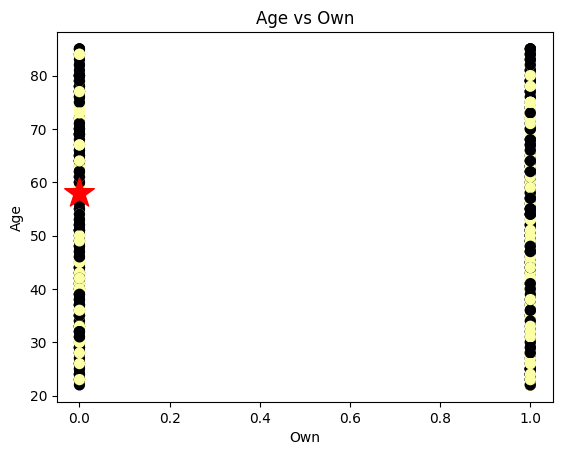

In [118]:
### Ubicamos este solicitante en la grafica Own/Age
import matplotlib.pyplot as plt
plt.scatter(XDArray[:,0], XDArray[:,2], c=YDArray, s=50, cmap='inferno')
plt.scatter(XDi[:,0], XDi[:,2], marker='*', s=500, facecolors='red')
plt.title('Age vs Own')
plt.xlabel('Own')
plt.ylabel('Age')
plt.show()

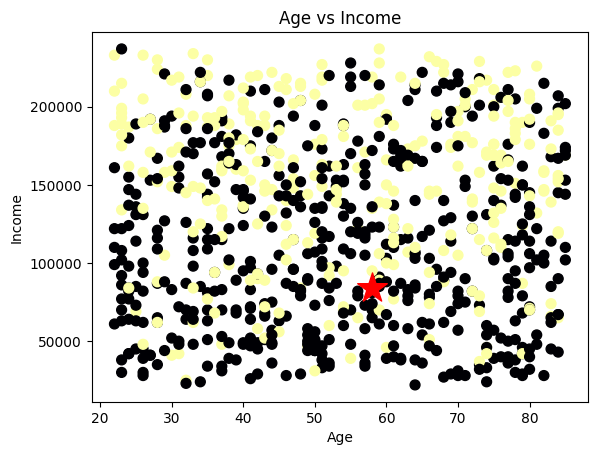

In [119]:
### Ubicamos este solicitante en la grafica Age/Income
import matplotlib.pyplot as plt
plt.scatter(XDArray[:,2], XDArray[:,3], c=YDArray, s=50, cmap='inferno')
plt.scatter(XDi[:,2], XDi[:,3], marker='*', s=500, facecolors='red')
plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [120]:
from sklearn.cluster import KMeans

np.random.seed(42)

k=5
kmeansmodel = KMeans(n_clusters=k, init='random', random_state=42)

kmeansmodel.fit(XDArray, YD)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(init='random', n_clusters=5, random_state=42)

In [121]:
labels = kmeansmodel.labels_
centroids = kmeansmodel.cluster_centers_

XDi = np.array([(0, 0, 58, 83931)])
Ydi = kmeansmodel.predict(XDi)

print(f'Este usuario pertenece al cluster:{Ydi}')

Este usuario pertenece al cluster:[1]


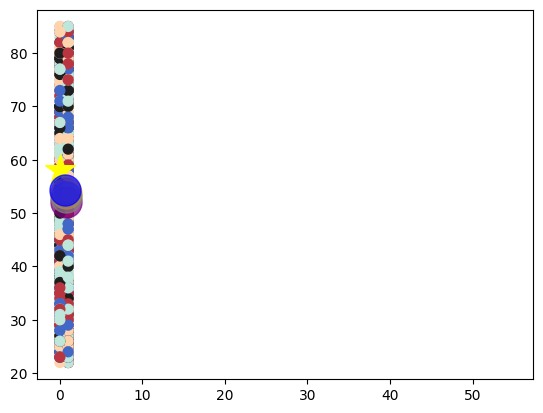

In [125]:

plt.scatter(XDArray[:,0], XDArray[:,2], c=labels, s=50, cmap='icefire')
plt.scatter(XDi[:,0], XDi[:,2], marker='*', s=500, facecolors='yellow')
plt.scatter(centroids[0,2], centroids[0,2], marker='o', s=500, alpha=0.7, facecolor='white')
plt.scatter(centroids[1,1], centroids[1,2], marker='o', s=500, alpha=0.7, facecolor='purple')
plt.scatter(centroids[2,1], centroids[2,2], marker='o', s=500, alpha=0.7, facecolor='orange')
plt.scatter(centroids[3,1], centroids[3,2], marker='o', s=500, alpha=0.7, facecolor='gray')
plt.scatter(centroids[4,1], centroids[4,2], marker='o', s=500, alpha=0.7, facecolor='blue')

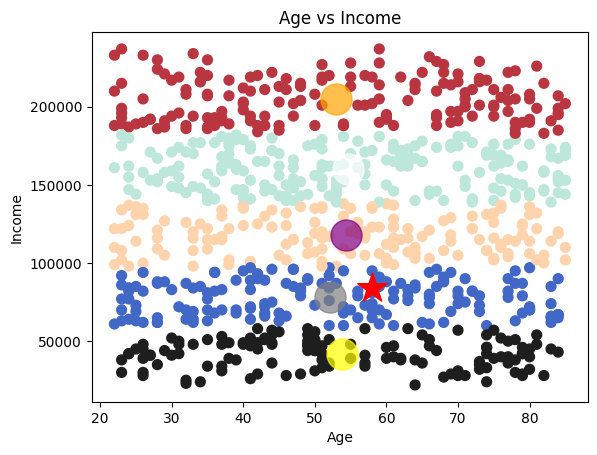

In [126]:
plt.scatter(XDArray[:,2], XDArray[:,3], c=labels, s=50, cmap='icefire')
plt.scatter(XDi[:,2], XDi[:,3], marker='*', s=500, facecolors='Red')
plt.scatter(centroids[0,2], centroids[0,3], marker='o', s=500, alpha=0.7, facecolor='white')
plt.scatter(centroids[1,2], centroids[1,3], marker='o', s=500, alpha=0.7, facecolor='gray')
plt.scatter(centroids[2,2], centroids[2,3], marker='o', s=500, alpha=0.7, facecolor='yellow')
plt.scatter(centroids[3,2], centroids[3,3], marker='o', s=500, alpha=0.7, facecolor='orange')
plt.scatter(centroids[4,2], centroids[4,3], marker='o', s=500, alpha=0.7, facecolor='purple')
plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [130]:
centroids
solicitantes.loc[:,'cluster'] = labels
counts_1 = np.bincount(labels)
counts_2 = solicitantes.groupby('cluster'). agg({'Rental': lambda x: (x==0).sum()})
counts_3 = solicitantes.groupby('cluster'). agg({'Rental': lambda x: (x==1).sum()})
df = pd.DataFrame(np.column_stack((counts_2, counts_3)))
df


,0,1
0,99,99
1,127,39
2,113,17
3,66,103
4,108,49


In [131]:
print( "Del cluster 0 se restan 99 individuos, del 1 39, del 2 17, del 3 103 y del 4 49")

Del cluster 0 se restan 99 individuos, del 1 39, del 2 17, del 3 103 y del 4 49


In [132]:
solicitantes[solicitantes['cluster']==0][['Own','Children','Age','Income']].describe()

,Own,Children,Age,Income
count,198.000000,198.000000,198.000000,198.000000
mean,0.611111,0.641414,54.641414,160146.464646
std,0.488734,0.480801,18.190411,12594.163608
min,0.000000,0.000000,22.000000,139000.000000
25%,0.000000,0.000000,39.000000,149000.000000
50%,1.000000,1.000000,53.000000,161500.000000
75%,1.000000,1.000000,71.000000,171000.000000
max,1.000000,1.000000,85.000000,182000.000000


In [133]:
solicitantes.groupby(['cluster'])['Own'].count().sort_values(ascending=True)

,Own
cluster,
2,130
4,157
1,166
3,169
0,198


In [134]:
solicitantes.groupby(['cluster'])['Children'].count().sort_values(ascending=False)

,Children
cluster,
0,198
3,169
1,166
4,157
2,130


In [135]:
solicitantes.groupby(['cluster'])['Age'].mean().sort_values(ascending=False)

,Age
cluster,
0,54.641414
4,54.382166
2,53.730769
3,53.011834
1,52.162651


In [136]:
solicitantes.groupby(['cluster'])['Income'].max().sort_values(ascending=False)

,Income
cluster,
3,237000
0,182000
4,138000
1,97000
2,58000


In [137]:
print("El cluster 0 es de mayor cantidad de personas con hijos y con mayor edad promedio, el 2 el que tiene el mayor numero de dueños y el 3 el que tiene el mayor numero de ingresos ")

El cluster 0 es de mayor cantidad de personas con hijos y con mayor edad promedio, el 2 el que tiene el mayor numero de dueños y el 3 el que tiene el mayor numero de ingresos 
